In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df = df.drop('customerID', axis=1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())
print(df.shape)

Churn
0    5174
1    1869
Name: count, dtype: int64
(7043, 20)


In [16]:
cat_cols = df.select_dtypes(include='str').columns.tolist()
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded = df_encoded.astype({col: int for col in df_encoded.select_dtypes(include='bool').columns})
print(df_encoded['Churn'].value_counts())
print(df_encoded.shape)

Churn
0    5174
1    1869
Name: count, dtype: int64
(7043, 31)


In [17]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train churn rate:", y_train.mean().round(2))
print("y_test churn rate:", y_test.mean().round(2))

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train churn rate: 0.27
y_test churn rate: 0.26


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Scale numerical columns
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Train models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")


Logistic Regression
Accuracy: 0.8211
F1 Score: 0.6390

Random Forest
Accuracy: 0.7871
F1 Score: 0.5253


In [19]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.4f}")

XGBoost
Accuracy: 0.7913
F1 Score: 0.5702


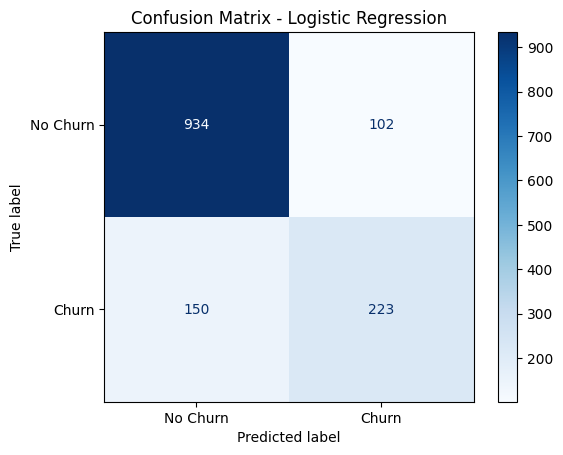

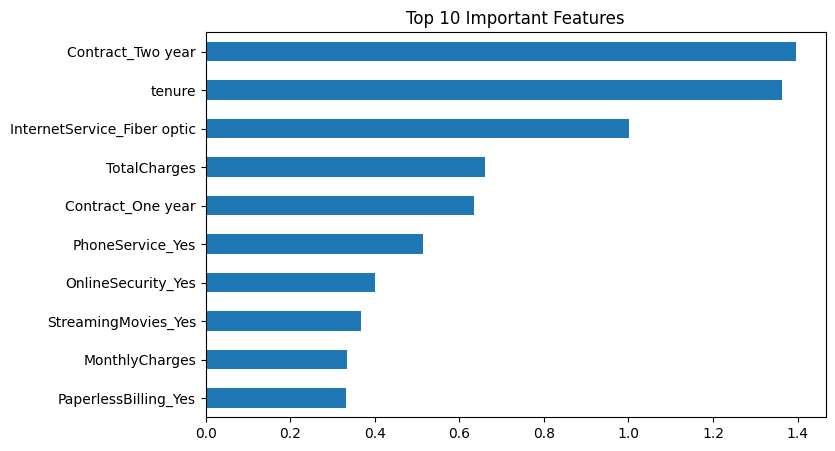

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = models['Logistic Regression']
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

importance = pd.Series(best_model.coef_[0], index=X_train.columns)
importance.abs().sort_values(ascending=False).head(10).plot(kind='barh', figsize=(8,5))
plt.title('Top 10 Important Features')
plt.gca().invert_yaxis()
plt.show()

In [21]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
